# EDA for Financial Change Prediction

**Data**
- `03_financial_change_labels.csv`
- `UKcompanies_active_account_category_sample_100k.csv`

**Purpose**
Provide the basis for preprocessing.

**Deliverable**
The final section produces two lists: settled constraints, and hypotheses to test, each with the
stage and method that will test it.

jupyter nbconvert --to html "01 EDA + Data PreProcessing/EDA_financial_change.ipynb"

In [1]:
# Environment and configuration

import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

#DATA_DIR = Path(".")
OUT_DIR = Path("eda_output")

PAIRS_PATH = "../01 EDA + Data PreProcessing/04_Five_CSV/03_financial_change_labels.csv"
META_PATH = "../01 EDA + Data PreProcessing/01_CompaniesSelected/UKcompanies_active_account_category_sample_100k.csv"

# the eleven financial metrics
METRICS = [
    "current_assets", "fixed_assets", "creditors_total", "equity",
    "net_assets_liabilities", "net_current_assets_liabilities",
    "cash", "debtors", "employees", "profit_loss",
    "total_assets_less_current_liabilities",
]

KEY = ["CompanyNumber_norm", "period_t", "period_t_plus_1"]
DATE_COLS = ["period_t", "period_t_plus_1", "available_date_t", "available_date_t_plus_1"]

TEST_SIZE = 0.20
RANDOM_STATE = 0

## 0. Data contract check

Verify the file matches the documentation.

In [2]:
# Load the pairs table

pairs = pd.read_csv(PAIRS_PATH, dtype={"CompanyNumber_norm": str}, low_memory=False)
for c in DATE_COLS:
    pairs[c] = pd.to_datetime(pairs[c], errors="coerce")

SUFFIXES = ["_t", "_t_plus_1", "_change_eligible", "_signed_log_change", "_percent_change",
            "_change_band", "_change_threshold_scope", "_change_threshold_n",
            "_change_low_threshold", "_change_high_threshold"]

checks = []
checks.append(("rows", f"{len(pairs):,}"))
checks.append(("companies", f"{pairs['CompanyNumber_norm'].nunique():,}"))
checks.append(("rows per company",
               f"{len(pairs) / pairs['CompanyNumber_norm'].nunique():.2f}"))
checks.append(("key unique", not pairs.duplicated(subset=KEY).any()))
checks.append(("columns", f"{pairs.shape[1]} (expected 122)"))

# leading zeros preserved
len_dist = pairs["CompanyNumber_norm"].str.len().value_counts().to_dict()
checks.append(("ID length", len_dist))

checks.append(("gap_days range",
               f"{pairs['gap_days'].min():.0f} ~ {pairs['gap_days'].max():.0f} "
               f"(expected 250~550)"))

elig_cols = [f"{m}_change_eligible" for m in METRICS]
missing_cols = [c for c in elig_cols if c not in pairs.columns]
checks.append(("11 eligible all present", not missing_cols))
if not missing_cols:
    checks.append(("count == eligible sum",
                   bool((pairs["change_available_field_count"] == pairs[elig_cols].sum(axis=1)).all())))

# suffix completeness
incomplete = {m: [s for s in SUFFIXES if f"{m}{s}" not in pairs.columns] for m in METRICS}
incomplete = {m: v for m, v in incomplete.items() if v}
checks.append(("11 × 10  suffixes complete", incomplete if incomplete else True))

for label, value in checks:
    print(f"{label:38s} : {value}")

rows                                   : 81,603
companies                              : 76,611
rows per company                       : 1.07
key unique                             : True
columns                                : 122 (expected 122)
ID length                              : {8: 81603}
gap_days range                         : 258 ~ 550 (expected 250~550)
11 eligible all present                : True
count == eligible sum                  : True
11 × 10  suffixes complete             : True


## 0.5 Joining the company metadata

The metadata table supplies company-level static attributes.

**Field classification**

| classification | Field |
|---|---
| Usable | `IncorporationDate`, `CompanyCategory`, `multi_sic_company` |
| Leaking | `Accounts_LastMadeUpDate`, `Accounts_NextDueDate` |
| Wrong time (not t) | `Mortgages_NumMortOutstanding`, `Mortgages_NumMortCharges`, `has_outstanding_charges`, `company_age_years` |
| Redundant | `has_fast_growth`, `matched_sectors`, `primary_sic_code` |
| Constant | `CompanyStatus`, `CountryOfOrigin`, `CountryOfOrigin_clean`, `is_uk_company` |
| Deferred | `RegAddress_*` |

`company_age_years` is measured as of 2026-05, which is a forward-looking view for a 2023/2024 pair. We recompute age at `period_t` from `IncorporationDate` instead.

**A note on sample scope**

All companies are Active, so dissolved companies are excluded by construction. This is a second layer of survivorship bias on top of "must have filed the t+1 accounts", and belongs in the limitations.

In [3]:
# Load metadata
meta_raw = pd.read_csv(META_PATH, dtype={"CompanyNumber": str}, low_memory=False)

def normalise_company_number(s):
    """
    strip non-alphanumerics, uppercase, zero-pad pure digits to 8"""
    s = re.sub(r"[^A-Za-z0-9]", "", str(s)).upper()
    return s.zfill(8) if s.isdigit() else s


meta_raw["CompanyNumber_norm"] = meta_raw["CompanyNumber"].map(normalise_company_number)

pair_companies = set(pairs["CompanyNumber_norm"])
print(f"before: {len(set(meta_raw['CompanyNumber']) & pair_companies):,}")
print(f"after: {len(set(meta_raw['CompanyNumber_norm']) & pair_companies):,}")
print(f"pair total: {len(pair_companies):,}")

# keep only the usable fields
META_KEEP = ["CompanyNumber_norm", "IncorporationDate", "CompanyCategory", "multi_sic_company"]
meta = meta_raw[META_KEEP].copy()
meta["IncorporationDate"] = pd.to_datetime(meta["IncorporationDate"], errors="coerce")

assert not meta["CompanyNumber_norm"].duplicated().any(), "duplicate IDs"

df = pairs.merge(meta, on="CompanyNumber_norm", how="left", validate="many_to_one")

# age at period_t, not at extraction time
df["company_age_at_t"] = (df["period_t"] - df["IncorporationDate"]).dt.days / 365.25

print(f"\nafter merge: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"unmatched: {df['IncorporationDate'].isna().sum():,}")
print(f"\ncompany_age_at_t quantiles:")
print(df["company_age_at_t"].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).round(1).to_string())

before: 44,875
after: 76,611
pair total: 76,611

after merge: 81,603 rows, 126 columns
unmatched: 0

company_age_at_t quantiles:
0.05     1.0
0.25     3.1
0.50     7.0
0.75    14.0
0.95    32.2


In [4]:
df.head()

,CompanyNumber_norm,CompanyName,primary_sector,Accounts_AccountCategory,period_t,period_t_plus_1,available_date_t,available_date_t_plus_1,gap_days,evidence_tier_t,...,total_assets_less_current_liabilities_change_band,total_assets_less_current_liabilities_change_threshold_scope,total_assets_less_current_liabilities_change_threshold_n,total_assets_less_current_liabilities_change_low_threshold,total_assets_less_current_liabilities_change_high_threshold,change_available_field_count,IncorporationDate,CompanyCategory,multi_sic_company,company_age_at_t
0,00031641,BARNSLEY ARCADE COMPANY LIMITED(THE),"Technology, legal & professional",SMALL,2024-05-31,2025-05-31,2025-02-28,2026-01-31,365.0,T2_balance_sheet_rich,...,High,sector_account_category,126.0,-0.059340,0.058377,10,1890-06-06,Private Limited Company,True,133.982204
1,00038191,WHARFEDALE FARMERS'AUCTION MART LIMITED,Agriculture,SMALL,2024-03-31,2025-03-31,2024-08-31,2025-08-31,365.0,T2_balance_sheet_rich,...,Medium,sector,1165.0,-0.080671,0.145952,10,1893-02-14,Private Limited Company,False,131.121150
2,00048896,PRESTON INCORPORATED LAW SOCIETY,"Public sector, education & charities",MICRO ENTITY,2023-12-31,2024-12-31,2024-10-31,2025-09-30,366.0,T2_balance_sheet_rich,...,NaN,NaN,NaN,NaN,NaN,3,1896-07-23,"PRI/LTD BY GUAR/NSC (Private, limited by guara...",False,127.436003
3,00048896,PRESTON INCORPORATED LAW SOCIETY,"Public sector, education & charities",MICRO ENTITY,2024-12-31,2025-12-31,2025-09-30,2026-04-30,365.0,T2_balance_sheet_rich,...,Medium,sector_account_category,1633.0,-0.194580,0.345050,6,1896-07-23,"PRI/LTD BY GUAR/NSC (Private, limited by guara...",False,128.438056
4,00054365,THE YORKSHIRE YACHT CLUB-HOUSE COMPANY LIMITED,"Public sector, education & charities",MICRO ENTITY,2023-12-31,2024-12-31,2024-11-30,2025-08-31,366.0,T2_balance_sheet_rich,...,Medium,sector_account_category,1633.0,-0.194580,0.345050,7,1897-10-09,Private Limited Company,False,126.223135


## 1. Splitting

**Primary split: grouped 80/20 by company**

About 12.19% of companies contribute two pairs, where the middle period is both the `t+1` of one pair and the `t` of the next. A random row split would place the same company on both sides.

All model, feature and target selection happens inside `train` via `GroupKFold`; `test` is
sealed and evaluated once at the end. 

**Time-based split**

The latest 20% by `available_date_t_plus_1`, excluding companies seen earlier.

In [5]:
# Primary split, grouped by company
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df["CompanyNumber_norm"]))

df["split_company"] = "train"
df.iloc[test_idx, df.columns.get_loc("split_company")] = "test"

# Time-based split
cutoff = df["available_date_t_plus_1"].quantile(1 - TEST_SIZE)
is_late = df["available_date_t_plus_1"] > cutoff
early_companies = set(df.loc[~is_late, "CompanyNumber_norm"])
df["split_time"] = np.where(
    is_late & ~df["CompanyNumber_norm"].isin(early_companies), "time_test", "time_train"
)

# statistics
for col in ["split_company", "split_time"]:
    stat = df.groupby(col).agg(
        rows=("CompanyNumber_norm", "size"),
        companies=("CompanyNumber_norm", "nunique"),
        period_t_min=("period_t", "min"),
        period_t_max=("period_t", "max"),
    )
    print(f"\n{col}\n{stat.to_string()}")


overlap = (set(df.loc[df.split_company == "train", "CompanyNumber_norm"])
           & set(df.loc[df.split_company == "test", "CompanyNumber_norm"]))
print(f"\ntrain/test company overlap: {len(overlap)}")


split_company
                rows  companies period_t_min period_t_max
split_company                                            
test           16310      15323   2020-07-31   2025-07-31
train          65293      61288   2019-04-30   2025-09-30

split_time
             rows  companies period_t_min period_t_max
split_time                                            
time_test    9509       9495   2022-09-30   2025-08-31
time_train  72094      67116   2019-04-30   2025-09-30

train/test company overlap: 0


In [6]:
# Save the split assignment
assignment = df[KEY + ["split_company", "split_time"]].copy()
assignment.to_csv(OUT_DIR / "split_assignment.csv", index=False, encoding="utf-8-sig")

# distribution consistency across the split
for col in ["primary_sector", "Accounts_AccountCategory", "evidence_tier_t"]:
    share = (df.groupby("split_company")[col]
               .value_counts(normalize=True).unstack(0).round(4))
    share["diff"] = (share["test"] - share["train"]).round(4)
    print(f"\n=== {col} ===")
    print(share.sort_values("diff", key=abs, ascending=False).head(6).to_string())

train = df[df["split_company"] == "train"].copy()
print(f"\ntrain: {len(train):,} rows / {train['CompanyNumber_norm'].nunique():,} companies")


=== primary_sector ===
split_company                       test   train    diff
primary_sector                                          
Healthcare                        0.0738  0.0778 -0.0040
Real Estate                       0.2565  0.2530  0.0035
Fast growth & emerging sector     0.0991  0.0964  0.0027
Agriculture                       0.0172  0.0161  0.0011
Manufacturing                     0.0702  0.0713 -0.0011
Technology, legal & professional  0.2676  0.2687 -0.0011

=== Accounts_AccountCategory ===
split_company               test   train    diff
Accounts_AccountCategory                        
MICRO ENTITY              0.5599  0.5521  0.0078
TOTAL EXEMPTION FULL      0.3763  0.3804 -0.0041
UNAUDITED ABRIDGED        0.0449  0.0487 -0.0038
SMALL                     0.0109  0.0095  0.0014
FULL                      0.0046  0.0053 -0.0007
GROUP                     0.0018  0.0024 -0.0006

=== evidence_tier_t ===
split_company               test   train    diff
evidence_tier_t     

## 2. Sample composition

1. How many rows per company? Determines the split.
2. Is the gap consistent? Determines comparability.
3. Are year-ends aligned? Determines whether seasonality influence the target.
4. Which years dominate? Determines drift risk.

Figures computed on the training set.

### 2.1 Grain

In [7]:
pairs_per_co = train.groupby("CompanyNumber_norm").size()
print(f"rows :{len(train):,}")
print(f"companies :{train['CompanyNumber_norm'].nunique():,}")
print(f"pairs per company:{pairs_per_co.value_counts().sort_index().to_dict()}")
print(f"share of rows from repeat companies: {(train['CompanyNumber_norm'].map(pairs_per_co) > 1).mean():.4f}")

rows :65,293
companies :61,288
pairs per company:{1: 57336, 2: 3918, 3: 21, 4: 7, 5: 6}
share of rows from repeat companies: 0.1219


### 2.2 Gap between periods

In [8]:
gap = train["gap_days"]
print(gap.quantile([0, .01, .25, .5, .75, .99, 1]).round(0).to_string())
print(f"within 350~380 days: {gap.between(350, 380).mean():.4f}")

0.00    258.0
0.01    365.0
0.25    365.0
0.50    365.0
0.75    366.0
0.99    367.0
1.00    550.0
within 350~380 days: 0.9862


### 2.3 Cohort & Year-end alignment

In [9]:
print("period_t year:")
print(train["period_t"].dt.year.value_counts(normalize=True).sort_index().round(4).to_string())

same_month = (train["period_t"].dt.month == train["period_t_plus_1"].dt.month)
same_day = same_month & (train["period_t"].dt.day == train["period_t_plus_1"].dt.day)
print(f"\nt & t+1 same month :{same_month.mean():.4f}")
print(f"t & t+1 same day :{same_day.mean():.4f}")
print("period_t month distribution:")
print(train["period_t"].dt.month.value_counts(normalize=True).head(12).round(4).to_string())

period_t year:
period_t
2019    0.0000
2020    0.0001
2021    0.0003
2022    0.0011
2023    0.1898
2024    0.7612
2025    0.0474

t & t+1 same month :0.9856
t & t+1 same day :0.9500
period_t month distribution:
period_t
3     0.2255
12    0.1252
6     0.0790
9     0.0743
4     0.0736
5     0.0656
7     0.0631
8     0.0628
10    0.0609
2     0.0586
1     0.0581
11    0.0533


### 2.4 Evidence tier 

In [10]:
print(train["evidence_tier_t"].value_counts(normalize=True, dropna=False).round(4).to_string())
tier_changed = (train["evidence_tier_t"] != train["evidence_tier_t_plus_1"])
print(f"tier changed between periods: {tier_changed.mean():.4f}")

evidence_tier_t
T2_balance_sheet_rich       0.9242
T3_balance_sheet_partial    0.0452
T1_observed_turnover        0.0255
T4_account_category_only    0.0051
tier changed between periods: 0.0444


### Reading the output

**Grain**
12.19% of rows come from companies contributing more than one pair (3918 with two and 34 with three to five). Their middle period is both the `t+1` of one pair and the `t` of the next, so the rows are not independent and both splitting and evaluation must be grouped by company. Note also that five pairs implies six distinct period-ends within a 24-month window. period-end parsing should be checked in the outlier section.

**Gap: highly consistent, no annualisation needed.**
98.62% fall within 350–380 days, with a median of 365 and the 1st/99th percentiles at 365 and 367.
Annualising by day count would do nothing for 99% of rows and would introduce odd values for the rest.The 1.38% outside this band (258 to 550 days, sitting right at the pairing window's edges) have year-ends at different seasonal points, mixing real change with seasonal difference. Keep them but flag with a binary `gap_irregular`** for sensitivity analysis rather than dropping them.

**Seasonality: Seasonality cancels in the target, but the feature is imbalanced**
98.56% of pairs share a month between t and t+1 (95.00% share the exact day), so seasonality cancels in the difference and does not contaminate the target. Features are level values at t, however, so month remains meaningful across companies and should be kept as a categorical feature. Note the distribution is heavily skewed — March accounts for 22.55% and December 12.52%, against 5.33% for November. Stratify evaluation by quarter rather than month.

**Cohort: concentrated in 2024, so drift risk is lower.**
2024 accounts for 76.12%, 2023 for 18.98% and 2025 for 4.74%, together 99.84%. Cross-year heterogeneity is therefore smaller than a "2019–2025" span implies. Rows from 2022 and earlier amount to under 0.2% and should be merged into 2023 or labelled "other" when stratifying, or some groups will contain only a few dozen rows.

We do not put year or any linear time index into the features. At deployment every row sits in a year the training set never saw, so any learned year effect cannot extrapolate. Month is fine, since seasons recur.

**Evidence tier: heavily imbalanced**
T2 accounts for 92.42%, T3 4.52%, T1 2.55% and T4 0.51% — heavily imbalanced, leaving only ~330 rows for T4 when stratifying. Only 4.44% of rows change tier between periods, so a derived "tier changed" feature would take the same value for 95.56% of rows: near-constant, with likely low marginal value, to be verified in feature ablation.

`evidence_tier_t` is visible at time t and is legitimate; `evidence_tier_t_plus_1` is future information and must not enter the model.

## 3. Missingness structure

Check missing rate and pattern: which fields go missing together, whether account category explains it, and whether a company discloses consistently across periods.

### 3.1 Missing rates, eligibility coverage, and rows dropped by the non-negativity rule

In [11]:
rows = []
for m in METRICS:
    t, t1 = train[f"{m}_t"], train[f"{m}_t_plus_1"]
    both = t.notna() & t1.notna()
    elig = train[f"{m}_change_eligible"].fillna(False).astype(bool)
    rows.append({
        "metric": m,
        "miss_t": t.isna().mean(),
        "miss_t1": t1.isna().mean(),
        "both_notna": both.mean(),
        "eligible": elig.mean(),
        # present in both periods yet not eligible = dropped by the non-negativity rule
        "dropped_by_sign": (both & ~elig).sum(),
        "zero_t": (t == 0).mean(),
    })

miss = pd.DataFrame(rows).sort_values("eligible", ascending=False).round(4)
print("dropped_by_sign > 0 means the field requires both periods ≥ 0; negatives are dropped\n")
miss


dropped_by_sign > 0 means the field requires both periods ≥ 0; negatives are dropped



,metric,miss_t,miss_t1,both_notna,eligible,dropped_by_sign,zero_t
3,equity,0.0294,0.0297,0.9654,0.9654,0,0.0118
8,employees,0.0469,0.0367,0.9431,0.9354,505,0.2432
5,net_current_assets_liabilities,0.0724,0.0465,0.9172,0.9172,0,0.0150
2,creditors_total,0.0663,0.0563,0.9211,0.9073,905,0.0303
10,total_assets_less_current_liabilities,0.1180,0.0989,0.8630,0.8630,0,0.0107
0,current_assets,0.1204,0.1092,0.8587,0.8559,183,0.0058
4,net_assets_liabilities,0.1629,0.1391,0.8225,0.8225,0,0.0113
1,fixed_assets,0.4756,0.4571,0.4941,0.4932,61,0.0154
6,cash,0.5777,0.5804,0.3929,0.3913,104,0.0019
7,debtors,0.6425,0.6367,0.3304,0.3281,153,0.0041


### 3.2 Co-missingness
Correlation between missing indicators. Highly correlated pairs may share one indicator

In [12]:
miss_ind = pd.DataFrame({m: train[f"{m}_t"].isna().astype(int) for m in METRICS})
co = miss_ind.corr()

pairs_hi = (co.where(np.triu(np.ones(co.shape), k=1).astype(bool))
              .stack().sort_values(ascending=False))
print("most co-missing field pairs:")
print(pairs_hi.head(8).round(3).to_string())

# Is missingness explained by account category?
print("\nmissing rate of _t by account category")
by_cat = (train.groupby("Accounts_AccountCategory")[[f"{m}_t" for m in METRICS]]
          .apply(lambda g: g.isna().mean()))
by_cat.columns = [c.replace("_t", "") for c in by_cat.columns]
by_cat["n"] = train.groupby("Accounts_AccountCategory").size()
print(by_cat.sort_values("n", ascending=False).round(3).to_string())

most co-missing field pairs:
cash                            debtors                                  0.801
net_current_assets_liabilities  total_assets_less_current_liabilities    0.594
creditors_total                 net_current_assets_liabilities           0.414
current_assets                  net_current_assets_liabilities           0.358
                                creditors_total                          0.345
                                total_assets_less_current_liabilities    0.288
net_assets_liabilities          net_current_assets_liabilities           0.269
creditors_total                 employees                                0.264

missing rate of _t by account category
                            current_assets  fixed_assets  creditorsotal  equity  net_assets_liabilities  net_current_assets_liabilities   cash  debtors  employees  profit_loss  total_assets_less_current_liabilities      n
Accounts_AccountCategory                                                     

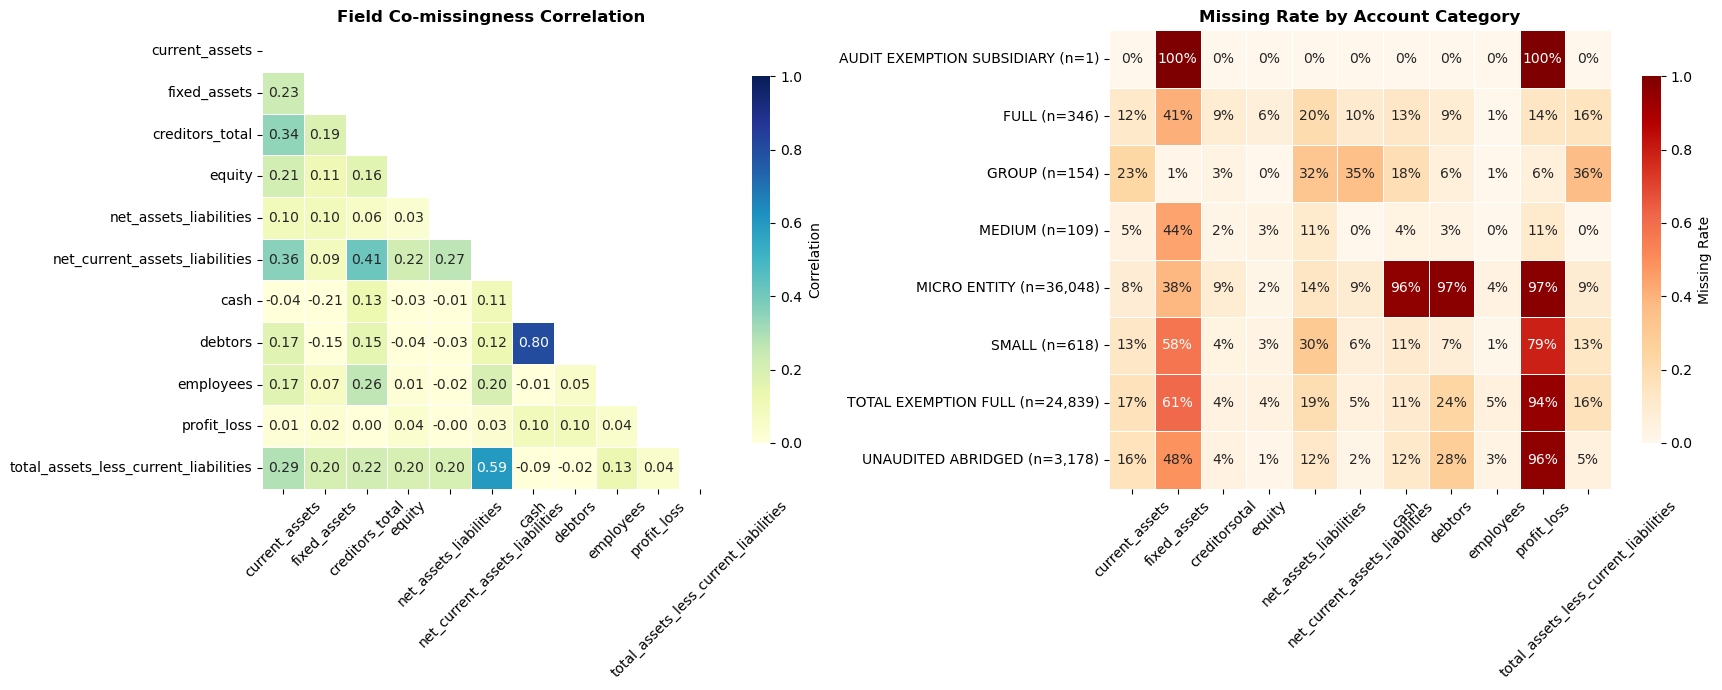

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. Co-missingness Correlation
mask = np.triu(np.ones_like(co, dtype=bool))

sns.heatmap(
    co,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    ax=ax1,
)
ax1.set_title("Field Co-missingness Correlation", fontsize=12, fontweight="bold")
ax1.tick_params(axis="x", rotation=45)


# 2. Missing Rate by Category)
plot_cat = by_cat.drop(columns=["n"]).copy()
plot_cat.index = [
    f"{idx} (n={by_cat.loc[idx, 'n']:,})" for idx in plot_cat.index
]

sns.heatmap(
    plot_cat,
    annot=True,
    fmt=".0%",
    cmap="OrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Missing Rate"},
    ax=ax2,
)
ax2.set_title(
    "Missing Rate by Account Category", fontsize=12, fontweight="bold"
)
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.3 Is disclosure a random event, or a company-level habit

In [14]:
# If independent, P(both) would equal the product of the marginals; a higher value means habit
rows = []
for m in METRICS:
    p_t = train[f"{m}_t"].notna().mean()
    p_t1 = train[f"{m}_t_plus_1"].notna().mean()
    p_both = (train[f"{m}_t"].notna() & train[f"{m}_t_plus_1"].notna()).mean()
    rows.append({
        "metric": m, "P_t": p_t, "P_t1": p_t1, "P_both": p_both,
        "if_independent": p_t * p_t1,
        "ratio": p_both / (p_t * p_t1) if p_t * p_t1 > 0 else np.nan,
        "P_t1_given_t": p_both / p_t if p_t > 0 else np.nan
    })

persist = pd.DataFrame(rows).sort_values("ratio", ascending=False).round(3)
print("ratio well above 1 means disclosure is a company-level habit, i.e. missingness is MNAR\n")
print(persist.to_string(index=False))

ratio well above 1 means disclosure is a company-level habit, i.e. missingness is MNAR

                               metric   P_t  P_t1  P_both  if_independent  ratio  P_t1_given_t
                          profit_loss 0.050 0.047   0.036           0.002 15.140         0.714
                              debtors 0.358 0.363   0.330           0.130  2.544         0.924
                                 cash 0.422 0.420   0.393           0.177  2.218         0.930
                         fixed_assets 0.524 0.543   0.494           0.285  1.736         0.942
               net_assets_liabilities 0.837 0.861   0.823           0.721  1.141         0.983
                       current_assets 0.880 0.891   0.859           0.784  1.096         0.976
total_assets_less_current_liabilities 0.882 0.901   0.863           0.795  1.086         0.978
                      creditors_total 0.934 0.944   0.921           0.881  1.045         0.987
       net_current_assets_liabilities 0.928 0.954   0.917

### Reading the output

**Coverage falls into three tiers, constraining the target shortlist.**

| Tier | Fields | eligible |
|---|---|---|
| High | equity, employees, net_current_assets_liabilities, creditors_total, TALCL, current_assets, net_assets_liabilities | 0.82–0.97 |
| Low | fixed_assets, cash, debtors | 0.33–0.49 |
| Unusable | profit_loss (but we keep it) | 0.036 |

Eligibility requires validity in both periods, so single-period missingness is roughly squared Low-coverage fields remain usable individually, but any multi-field intersection shrinks sharply. The solution is fitting one model per metric on its own eligible subset. `profit_loss` has only ~2350 rows, too few for stable five-fold evaluation, but keeping it as a feature is harmless, since GBM handles NaN natively. So we still use it as a target, although unreliable.

**`dropped_by_sign` exposes dirty data the upstream flag misses.**

1,911 field-rows carry impossible negatives, led by `creditors_total` (905) and `employees` (505). The five sign-permitted fields show zero, as expected.

**Co-missingness: only one pair is redundant enough to merge.**

The missing indicators for `cash` and `debtors` correlate at 0.801 — they almost always go
missing together and could share a single indicator. Other pairs range from 0.26 to 0.59, moderate
but not redundant enough to merge.

**Account category explains most missingness — but not all.**

Cash and debtors missingness is almost entirely determined by account category — micro entities
rarely disclose either, while Total Exemption Full companies mostly do. Given that`Accounts_AccountCategory` is already a feature, the `cash`/`debtors` missing indicators add little. 

`fixed_assets` behaves differently: its missing rate runs 0.383 for MICRO, 0.610 for TEF, 0.483 for ABRIDGED, 0.578 for SMALL, 0.408 for FULL and 0.013 for GROUP — the ordering contradicts what disclosure depth would suggest, with micro entities missing it less often than Total Exemption Full. Something beyond category drives it. Its indicator may carry independent information and is retained.


**The category variable is heavily imbalanced and needs merging.**

MICRO ENTITY holds 55.2% and TOTAL EXEMPTION FULL 38.0%; five categories together account for 1.9%,
one of them a single row. Tiny categories cause tree models to fit splits on noise, and a single-row category is necessarily absent from some training folds, sending predictions down the unknown branch. Merge the 4 categories (except `GROUP`) under 1,000 rows into `OTHER`, reducing eight categories to four. The merge rule should be defined within the training fold.

GROUP's missingness runs opposite to every other category. It almost always reports fixed assets yet frequently omits net current assets and TALCL. It is not the same kind of thing as SMALL / MEDIUM / FULL.

**the conditional probability**

The conditional probability indicates every field exceeds 0.92 except `profit_loss` at 0.720. 28% of companies that disclosed profit last period do not the next. It is the least stable field, giving a second reason to exclude it alongside sample size.

**Zero or missing.**

Apart from `employees` (24.32%), all fields have zero rates below 3%. `employees = 0` is a meaningful
business state which means the company genuinely has no staff, common for single-shareholder or holding
vehicles and is not a missing value. 

So we do not `fillna(0)`: tree models keep the two distinct natively, while the linear-model branch must use median imputation plus an indicator.

---

### Conclusions

**Settled**
1. Keep all 11 as targets, flag `profit_loss` as unreliable.
2. Merge to five categories by business logic, keeping GROUP separate.(`Accounts_AccountCategory`)
3. Retain the raw eight-category column.
4. Keep all 11 missing indicators.
5. No `fillna(0)` in preprocessing.

If GROUP proves unstable at 154 rows, fall back to frequency merging.

Indicators for co-missing fields(`cash`, `debtors`) can be merged

**Limitations**
Missingness in the low-coverage fields(`cash` 39.1%, `debtors` 32.8%) is largely determined by account category, so their models train on a population skewed toward fuller disclosers and do not extrapolate to companies that never disclose those fields.

## 4. Target characteristics

All eleven fields are retained as targets, so this section selects nothing. It establishes what
each target looks like, as a reference for interpreting later results. Three things:

Figures are computed on the training set, each field using only its own eligible rows.

### 4.1 Distribution shape

In [15]:
rows = []
for m in METRICS:
    e = train[f"{m}_change_eligible"].fillna(False).astype(bool)
    y = train.loc[e, f"{m}_signed_log_change"].dropna()
    if len(y) < 200:
        continue
    q = y.quantile([.01, .05, .25, .5, .75, .95, .99])
    rows.append({
        "metric": m, "n": len(y),
        "zero_frac": float((y == 0).mean()),
        "P1": q[.01], "P25": q[.25], "P50": q[.5], "P75": q[.75], "P99": q[.99],
        "std": y.std(),
        "IQR": q[.75] - q[.25],
        # tail heaviness relative to the IQR
        "tail_ratio": (q[.99] - q[.01]) / (q[.75] - q[.25]) if q[.75] > q[.25] else np.nan,
        "kurtosis": y.kurtosis(),
    })

shape = pd.DataFrame(rows).sort_values("tail_ratio", ascending=False).round(3)
print("(P99-P1)/IQR ≈ 3.4 under normality, higher means heavier tails\n")
print(shape.to_string(index=False))

(P99-P1)/IQR ≈ 3.4 under normality, higher means heavier tails

                               metric     n  zero_frac      P1    P25    P50   P75    P99   std   IQR  tail_ratio  kurtosis
total_assets_less_current_liabilities 56348      0.062 -19.241 -0.251  0.000 0.243 18.368 4.629 0.493      76.237    13.080
                               equity 63033      0.128 -18.849 -0.235  0.000 0.301 18.571 4.964 0.536      69.779     9.516
               net_assets_liabilities 53706      0.061 -19.440 -0.262  0.004 0.342 18.983 5.093 0.604      63.638     9.543
       net_current_assets_liabilities 59887      0.055 -21.502 -0.375  0.000 0.314 21.027 6.076 0.689      61.710     7.263
                         fixed_assets 32203      0.240  -4.637 -0.226 -0.000 0.002  3.987 1.288 0.228      37.746    43.069
                          profit_loss  2351      0.033 -25.885 -0.781  0.000 0.653 25.904 8.607 1.434      36.111     3.355
                      creditors_total 59239      0.066  -5.133 -0.18

C:\Users\86132\AppData\Local\Temp\ipykernel_21552\3502895111.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data, vert=False, labels=order, whis=(1, 99), showfliers=False, widths=0.6)


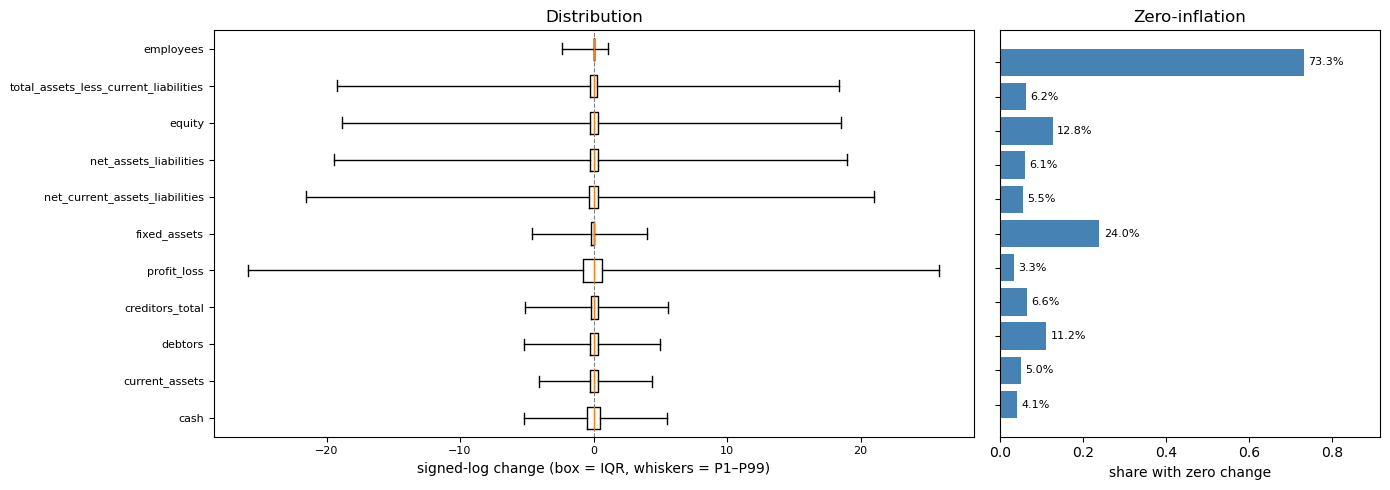

In [19]:
# Visualising the shape
# Left: boxplots (range clipped to show the body; extremes are covered by the table above)
# Right: zero-inflation, which determines how strong the "no change" baseline is

import matplotlib.pyplot as plt

order = shape.sort_values("tail_ratio")["metric"].tolist()
data = [train.loc[train[f"{m}_change_eligible"].fillna(False).astype(bool),
                  f"{m}_signed_log_change"].dropna() for m in order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),
                               gridspec_kw={"width_ratios": [2, 1]})

ax1.boxplot(data, vert=False, labels=order, whis=(1, 99), showfliers=False, widths=0.6)
ax1.axvline(0, color="grey", lw=0.8, ls="--")
ax1.set_xlabel("signed-log change (box = IQR, whiskers = P1–P99)")
ax1.set_title("Distribution")
ax1.tick_params(labelsize=8)

zf = shape.set_index("metric").loc[order, "zero_frac"]
bars = ax2.barh(range(len(order)), zf.values, color="steelblue")
ax2.set_yticks(range(len(order)))
ax2.set_yticklabels([])
ax2.set_xlabel("share with zero change")
ax2.set_title("Zero-inflation")
for i, v in enumerate(zf.values):
    ax2.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=8)
ax2.set_xlim(0, max(zf.max() * 1.25, 0.1))

fig.tight_layout()
plt.show()

### 4.2 Sign-crossing rows

In [17]:
# Only the four sign-permitted fields can cross zero; the other seven require both periods ≥ 0

SIGN_FIELDS = ["equity", "net_assets_liabilities",
               "net_current_assets_liabilities", "total_assets_less_current_liabilities"]

rows = []
for m in SIGN_FIELDS:
    e = train[f"{m}_change_eligible"].fillna(False).astype(bool)
    sub = train.loc[e, [f"{m}_t", f"{m}_t_plus_1", f"{m}_signed_log_change"]].dropna()
    t, t1, y = sub[f"{m}_t"], sub[f"{m}_t_plus_1"], sub[f"{m}_signed_log_change"]

    crossed = (np.sign(t) != np.sign(t1)) & (t != 0) & (t1 != 0)
    # their share of total squared deviation
    ss = (y - y.mean()) ** 2

    rows.append({
        "metric": m, "n": len(sub),
        "cross_frac": float(crossed.mean()),
        "pos_to_neg": float(((t > 0) & (t1 < 0)).mean()),
        "neg_to_pos": float(((t < 0) & (t1 > 0)).mean()),
        "median_abs_crossed": float(y[crossed].abs().median()) if crossed.any() else np.nan,
        "median_abs_same": float(y[~crossed].abs().median()),
        # Proportion of target total squared deviation cross-zero row contribution
        "var_share_crossed": float(ss[crossed].sum() / ss.sum()),
    })

cross = pd.DataFrame(rows).round(4)
cross

,metric,n,cross_frac,pos_to_neg,neg_to_pos,median_abs_crossed,median_abs_same,var_share_crossed
0,equity,63033,0.0793,0.0416,0.0376,16.1022,0.2213,0.8854
1,net_assets_liabilities,53706,0.0840,0.0465,0.0375,16.4254,0.2512,0.9237
2,net_current_assets_liabilities,59887,0.1086,0.0613,0.0474,17.3114,0.2651,0.9535
3,total_assets_less_current_liabilities,56348,0.0647,0.0368,0.0279,16.9154,0.2118,0.9213


### 4.3 Correlation between targets

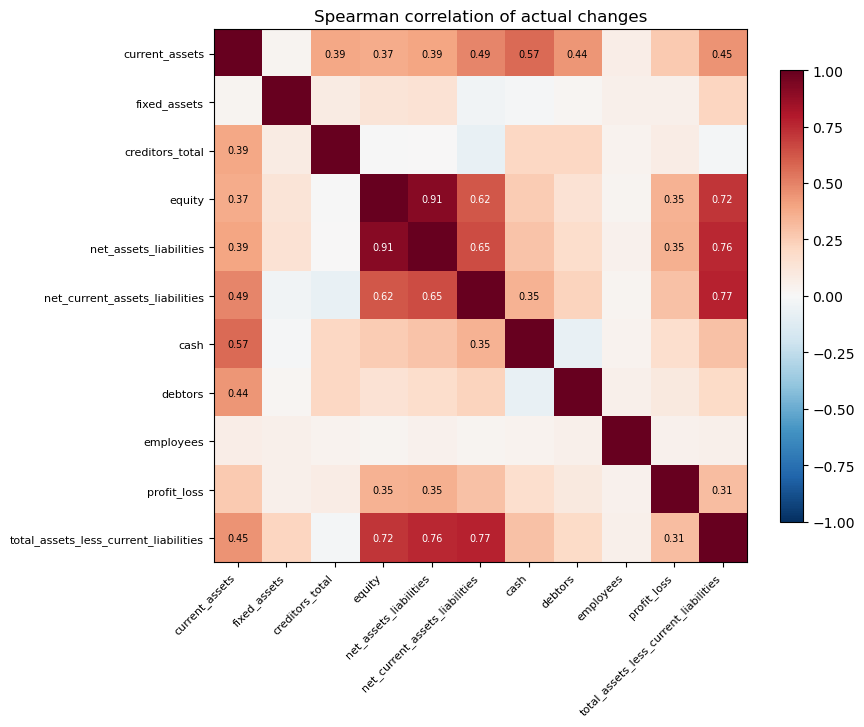


most correlated target pairs:
equity                          net_assets_liabilities                   0.911
net_current_assets_liabilities  total_assets_less_current_liabilities    0.773
net_assets_liabilities          total_assets_less_current_liabilities    0.757
equity                          total_assets_less_current_liabilities    0.718
net_assets_liabilities          net_current_assets_liabilities           0.653
equity                          net_current_assets_liabilities           0.621
current_assets                  cash                                     0.566
                                net_current_assets_liabilities           0.488


In [18]:
# computed pairwise on rows eligible for both

chg = pd.DataFrame({
    m: train[f"{m}_signed_log_change"].where(
        train[f"{m}_change_eligible"].fillna(False).astype(bool))
    for m in METRICS
})
corr = chg.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        if i != j and abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.6 else "black")
ax.set_title("Spearman correlation of actual changes")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

pairs_hi = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
              .stack().sort_values(key=abs, ascending=False))
print("\nmost correlated target pairs:")
print(pairs_hi.head(8).round(3).to_string())

### Reading the output

**Tails are far heavier than any normal assumption.**
`tail_ratio` is about 3.4 under normality. The four sign-permitted fields measure 61.7–76.2. The body and the tails are entirely disconnected.

**A few sign-crossing rows account for nearly all squared deviation.**
Sign-crossing rows show absolute changes dozens of times larger than same-sign rows, so under a tenth of the rows carry close to 90% of the squared deviation. 

The continuous change for these fields describes two different things at once: magnitude, and state transition (for example, positive to negative equity is insolvency).

**Conclusion 1: squared loss is not usable.**
Squared loss allocates its optimisation weight in proportion to squared deviation. For these four
fields roughly 90% of that weight would fall on under 10% of rows, so the model would chiefly fit which companies cross zero while barely separating the rest. Use quantile loss (q=0.5) or another absolute-error-based robust loss throughout.

**Conclusion 2: evaluation must be rank-based.**
- Spearman
- Pairwise accuracy + discrimination rate
- Decile profile on medians 

The same figures rule out value-based evaluation. RMSE, R² and skill score all rest on squared deviation and would chiefly measure accuracy on the sign-crossing rows. Rank-based metrics are used instead, and the decile profile must use medians: means are equally tail-driven and give the opposite conclusion.

**Zero-inflation sets the baseline, so metrics are not comparable across fields.**
`employees` shows 73.3% zero change, with P25, P50 and P75 all at zero, an IQR of zero and an undefined `tail_ratio`. For such fields the "no change" baseline is exactly right on most rows and
very hard to beat, so every metric must be reported alongside `zero_frac`. Zero-inflation also depresses the discrimination rate: the model returns identical predictions for many companies, whose
percentiles are then undefined.

**The distribution of `profit_loss` shows it is not usable.**
With only 2,351 rows and the widest spread of any field, its results should be flagged unreliable.

---

### Conclusions

**Settled**
1. Use quantile (q=0.5) or other robust loss throughout, not squared loss.
2. Evaluate with rank-based metrics only.
3. Decile profiles on medians, means for reference only.
4. Report every metric alongside `zero_frac`.
5. Keep `profit_loss` but flag its results unreliable.

## 5. Feature distributions and outliers

signed-log is strictly monotone and tree models split on order alone. The transform is inert for trees, so it is not a decision to be made here. It is retained for compatibility with the linear baseline and for readable partial-dependence axes, not as a performance improvement.

### 5.1 Impossible negative values

In [19]:
def signed_log1p(x):
    """Sign-preserving log transform: sign(x)*ln(1+|x|)"""
    x = pd.to_numeric(x, errors="coerce")
    return np.sign(x) * np.log1p(np.abs(x))

In [20]:
# set to NaN, since the value is untrustworthy and unrecoverable so only the extent matters
NONNEG = ["current_assets", "fixed_assets", "creditors_total",
          "cash", "debtors", "employees"]

rows = []
for m in NONNEG:
    for suf in ("_t", "_t_plus_1"):
        v = train[f"{m}{suf}"]
        rows.append({"metric": m, "period": suf,
                     "n_neg": int((v < 0).sum()),
                     "share_of_present": float((v < 0).sum() / v.notna().sum())})

neg = (pd.DataFrame(rows).pivot(index="metric", columns="period",
                                values=["n_neg", "share_of_present"])
       .round(4))
print(neg.to_string())

# Eligibility filters only the target's own field; the other ten reach the feature matrix
contaminated = pd.DataFrame({m: (train[f"{m}_t"] < 0) for m in NONNEG}).any(axis=1)
print(f"\nrows with ≥1 impossible negative feature: "
      f"{contaminated.sum():,} ({contaminated.mean():.2%})")

                 n_neg           share_of_present          
period              _t _t_plus_1               _t _t_plus_1
metric                                                     
cash              68.0      95.0           0.0025    0.0035
creditors_total  647.0     701.0           0.0106    0.0114
current_assets   119.0     146.0           0.0021    0.0025
debtors          121.0     134.0           0.0052    0.0056
employees        467.0     157.0           0.0075    0.0025
fixed_assets      37.0      60.0           0.0011    0.0017

rows with ≥1 impossible negative feature: 1,373 (2.10%)


### 5.2 MetaData

In [21]:
# CompanyCategory
print("\nCompanyCategory:")
cat = train["CompanyCategory"]
print(f"\nmissing: {cat.isna().sum():,} ({cat.isna().mean():.2%})")
print(cat.nunique())
print(cat.unique())
print('\n')
print(cat.value_counts(normalize=True).round(6).to_string())
train.groupby("CompanyCategory").size()


CompanyCategory:

missing: 0 (0.00%)
7
['Private Limited Company'
 'PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)'
 'Private Unlimited Company' 'Public Limited Company'
 "PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)"
 'Private Unlimited' 'Community Interest Company']


CompanyCategory
Private Limited Company                                                                      0.969231
PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)                        0.022805
PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)    0.005391
Community Interest Company                                                                   0.002297
Private Unlimited Company                                                                    0.000153
Public Limited Company                                                                       0.000107
Private Unlimited               

CompanyCategory
Community Interest Company                                                                     150
PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)      352
PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)                         1489
Private Limited Company                                                                      63284
Private Unlimited                                                                                1
Private Unlimited Company                                                                       10
Public Limited Company                                                                           7
dtype: int64

In [22]:
print(f"\nmulti_sic_company: {train['multi_sic_company'].mean():.4f}")
print(train["multi_sic_company"].value_counts(normalize=True).round(6).to_string())
train['multi_sic_company'].isna().sum()


multi_sic_company: 0.2391
multi_sic_company
False    0.760878
True     0.239122


np.int64(0)

In [23]:
# Age distribution
age = train["company_age_at_t"]
print(age.quantile([0, .01, .25, .5, .75, .99, 1]).round(2).to_string())
print(f"\nmissing: {age.isna().sum():,} ({age.isna().mean():.2%})")
print(f"negative: {(age < 0).sum():,}")
print(f"under one year : {(age < 1).sum():,}")
print(f"over 100 years : {(age > 100).sum():,}")

0.00      0.03
0.01      1.00
0.25      3.06
0.50      7.05
0.75     14.02
0.99     59.39
1.00    133.98

missing: 0 (0.00%)
negative: 0
under one year : 654
over 100 years : 46


### 5.3 Magnitude check

In [24]:
# Not to decide winsorising (trees are insensitive to extremes) but to spot parsing errors
rows = []
for m in METRICS:
    v = pd.to_numeric(train[f"{m}_t"], errors="coerce").dropna()
    if len(v) < 200:
        continue
    q = v.quantile([.01, .5, .99])
    rows.append({
        "metric": m, "n": len(v),
        "min": v.min(), "P1": q[.01], "P50": q[.5], "P99": q[.99], "max": v.max(),
        "zero_rate": float((v == 0).mean()),
        # max relative to P99; hundreds of times over usually means a unit or scale error
        "max_vs_P99": v.max() / q[.99] if q[.99] > 0 else np.nan,
    })

mag = pd.DataFrame(rows).sort_values("max_vs_P99", ascending=False)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(mag.to_string(index=False))
pd.reset_option("display.float_format")

print("\nabsolute values above 1e12:")
for m in METRICS:
    v = pd.to_numeric(train[f"{m}_t"], errors="coerce")
    n = (v.abs() > 1e12).sum()
    if n:
        print(f"  {m:38s} {n:,}")

                               metric     n               min            P1       P50          P99              max  zero_rate  max_vs_P99
                            employees 62233            -98.00          0.00      1.00        49.00     6,091,683.00       0.26  124,320.06
                       current_assets 57434       -396,752.00          1.00 31,189.00 5,178,505.26 3,032,725,000.00       0.01      585.64
                              debtors 23345       -836,725.00          0.00 22,021.00 5,575,388.40 2,990,801,000.00       0.01      536.43
                      creditors_total 60964    -60,328,000.00       -100.00 23,833.50 2,669,361.01   392,837,000.00       0.03      147.17
       net_current_assets_liabilities 60568 -2,929,788,000.00 -1,318,468.93  5,632.00 2,778,519.70   274,953,000.00       0.02       98.96
                         fixed_assets 34241     -1,237,845.00          0.00 10,980.00 5,105,822.40   245,274,772.00       0.03       48.04
                           

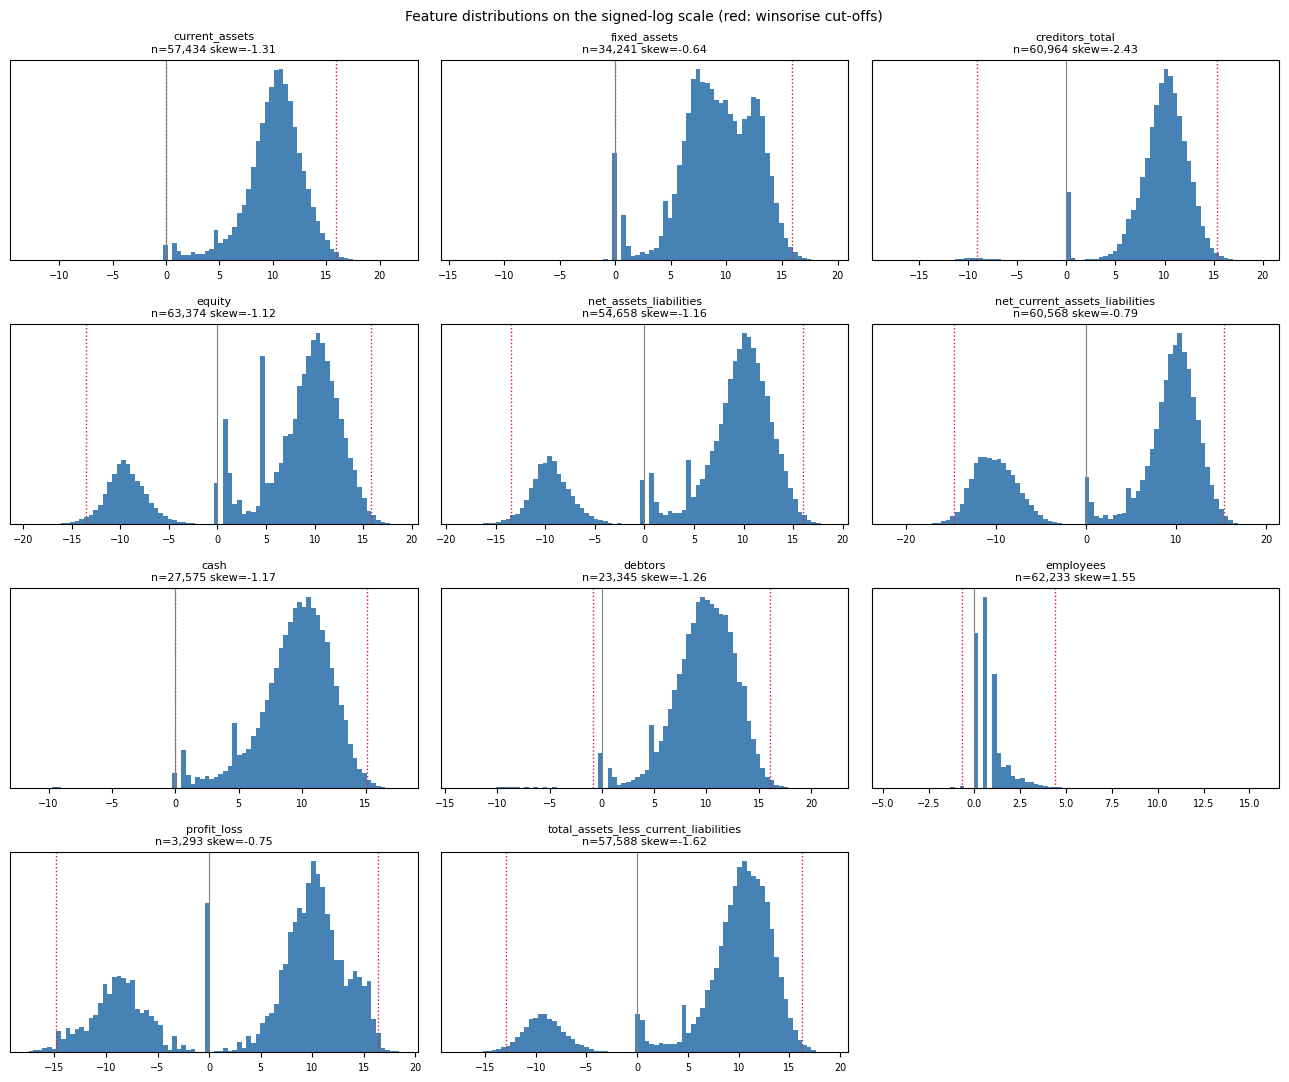

In [25]:
fig, axes = plt.subplots(4, 3, figsize=(13, 11))
axes = axes.ravel()

for ax, m in zip(axes, METRICS):
    v = signed_log1p(train[f"{m}_t"]).dropna()
    ax.hist(v, bins=80, color="steelblue", edgecolor="none")
    for q, style in [(0.005, ":"), (0.995, ":")]:
        ax.axvline(v.quantile(q), color="crimson", ls=style, lw=1)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_title(f"{m}\nn={len(v):,} skew={v.skew():.2f}", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_yticks([])

for ax in axes[len(METRICS):]:
    ax.set_visible(False)

fig.suptitle("Feature distributions on the signed-log scale (red: winsorise cut-offs)",
             fontsize=10)
fig.tight_layout()
plt.show()

In [28]:
# Diagnosing extreme headcount values
# A common failure mode is a monetary value tagged as headcount. If it matches another
# field in the same row, the mis-tag is confirmed

MONEY = ["current_assets", "fixed_assets", "creditors_total", "cash", "debtors",
         "equity", "net_assets_liabilities", "net_current_assets_liabilities",
         "total_assets_less_current_liabilities"]

top = train.nlargest(30, "employees_t").copy()

def matching_money(row, tol=0.01):
    e = row["employees_t"]
    hits = [m for m in MONEY
            if pd.notna(row[f"{m}_t"]) and abs(row[f"{m}_t"] - e) <= tol * max(abs(e), 1)]
    return ",".join(hits) if hits else ""

top["matches"] = top.apply(matching_money, axis=1)

cols = ["CompanyName", "acct_cat_raw", "employees_t", "current_assets_t",
        "creditors_total_t", "equity_t", "matches"]
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
print(top[cols].to_string(index=False))
pd.reset_option("display.float_format")

                          CompanyName         acct_cat_raw  employees_t  current_assets_t  creditors_total_t    equity_t                                                                                            matches
           OXFORD BIOTHERAPEUTICS LTD                GROUP    6,091,683        15,811,411          7,648,645  -1,149,635                                                                                            debtors
             CAKESMITHS GROUP LIMITED                 FULL      161,000         8,906,000          2,763,000   8,174,000                                                                                                   
                         MCBRAIDA PLC                 FULL      144,000        24,380,000            492,000  18,472,000                                                                                                   
                       IVOLVE CMC LTD                 FULL      144,000         7,660,000            271,000   5,072,000

In [ ]:
# Cleaning implausible headcount
# Two rules: an absolute ceiling, and conflict with the account category's own definition
e = train["employees_t"]

implausible = (
    (e > 1500)
    | ((train["acct_cat_raw"] == "MICRO ENTITY") & (e > 50))   # legal limit 10
)
print(f"rows to clean: {implausible.sum():,} ({implausible.mean():.3%})")
print(train.loc[implausible, ["CompanyName", "acct_cat_raw", "employees_t"]]
      .sort_values("employees_t", ascending=False).head(20).to_string(index=False))

rows to clean: 26 (0.040%)
                                        CompanyName         acct_cat_raw  employees_t
                         OXFORD BIOTHERAPEUTICS LTD                GROUP    6091683.0
                           CAKESMITHS GROUP LIMITED                 FULL     161000.0
                                     IVOLVE CMC LTD                 FULL     144000.0
                                       MCBRAIDA PLC                 FULL     144000.0
                                      NEXOR LIMITED               MEDIUM      64000.0
                         GUNTERSTONE STUDIO LIMITED         MICRO ENTITY      12509.0
                                   KAYES DESIGN LTD         MICRO ENTITY       7862.0
                               CARL WEHOFER LIMITED TOTAL EXEMPTION FULL       2023.0
                               JAIN ESTATES LIMITED                SMALL       2022.0
                                  HAP FLEXI LIMITED                 FULL       2021.0
                       IVOL

### 5.4 Imputation statistics for the linear baseline

In [27]:
# Apply the decisions from 3
CATEGORY_MAP = {
    "MICRO ENTITY":               "MICRO",
    "TOTAL EXEMPTION FULL":       "TEF",
    "UNAUDITED ABRIDGED":         "ABRIDGED",
    "GROUP":                      "GROUP",
    "SMALL":                      "FULL_DISCLOSURE",
    "MEDIUM":                     "FULL_DISCLOSURE",
    "FULL":                       "FULL_DISCLOSURE",
    "AUDIT EXEMPTION SUBSIDIARY": "FULL_DISCLOSURE",
}

for frame in (df, train):
    frame["acct_cat_raw"] = frame["Accounts_AccountCategory"]
    frame["acct_cat_model"] = (frame["Accounts_AccountCategory"]
                               .map(CATEGORY_MAP).fillna("FULL_DISCLOSURE"))

print(train["acct_cat_model"].value_counts().to_string())

acct_cat_model
MICRO              36048
TEF                24839
ABRIDGED            3178
FULL_DISCLOSURE     1074
GROUP                154


In [29]:
# Tree models handle NaN natively; this section serves the Ridge branch only
# High-coverage fields only: elsewhere the imputed value cannot represent the imputed population
HIGH_COV = [m for m in METRICS
            if train[f"{m}_t"].notna().mean() >= 0.80]
print(f"high-coverage fields (≥80%): {HIGH_COV}\n")

rows = []
for m in METRICS:
    v = signed_log1p(train[f"{m}_t"]).dropna()
    iqr = v.quantile(.75) - v.quantile(.25)
    g = signed_log1p(train[f"{m}_t"]).groupby(train["acct_cat_raw"]).median()
    rows.append({
        "metric": m,
        "coverage": train[f"{m}_t"].notna().mean(),
        "mean": v.mean(), "median": v.median(),
        # mean−median scaled by IQR; near zero means the transform has symmetrised it
        "mean_median_gap": (v.mean() - v.median()) / iqr if iqr else np.nan,
        "group_median_min": g.min(), "group_median_max": g.max(),
        # spread of group medians relative to the global IQR
        "group_spread_vs_iqr": (g.max() - g.min()) / iqr if iqr else np.nan,
    })

print(pd.DataFrame(rows).round(3).to_string(index=False))

high-coverage fields (≥80%): ['current_assets', 'creditors_total', 'equity', 'net_assets_liabilities', 'net_current_assets_liabilities', 'employees', 'total_assets_less_current_liabilities']

                               metric  coverage   mean  median  mean_median_gap  group_median_min  group_median_max  group_spread_vs_iqr
                       current_assets     0.880 10.023  10.348           -0.107             9.764            15.684                1.945
                         fixed_assets     0.524  9.212   9.304           -0.019             8.643            13.509                1.017
                      creditors_total     0.934  9.592  10.079           -0.166             9.636            14.876                1.787
                               equity     0.971  5.671   8.726           -0.357           -12.204            14.943                3.174
               net_assets_liabilities     0.837  5.854   9.117           -0.465           -12.204            15.140        

### Reading the output

**Impossible negatives require feature-side handling.**
Around 1,459 `_t` values are negative across the six fields that cannot be negative, between 0.1% and 1.1% of present values, concentrated in `creditors_total` (647) and `employees` (467). The cause
cannot be established from the data at hand, but whatever it is, the values are untrustworthy and unrecoverable, so they are set to NaN and treated as undisclosed. Truncating to zero would assert that the company genuinely has none, which is probably false.

1,373 rows (2.10%) carry at least one such value. 

Eligibility filters only the target's own field, so negatives in the other ten reach the feature matrix regardless. The fix must be applied feature-side.


**`employees` carries several identifiable parsing errors.**

Its P99 is 49 yet the maximum reaches 6,091,683. Inspecting the thirty largest values reveals some
distinct error patterns:
1. Monetary value mis-tagged. 6,091,683(employees) = `debtors` in this row；727(employees) = `equity`.
2. Year mis-tagged: 2,023 / 2,022 / 2,021 / 2,000 `employees`
3. Scale off by 1000: 161,000 / 144,00 / 64,000 

The first pattern is the hardest to spot: 727 is unremarkable on its own and was identified only because it exactly matches that row's `equity`. No single numeric threshold catches this class of error. Values below roughly 1,300 are consistent with company size and mark the upper bound of the  range.

**Cleaning rule** 
Two rules combined, affecting 26 rows (0.04%):
1. headcount above 1,500, which exceeds the plausible range for this sample. 
2. MICRO ENTITY companies reporting more than 50, since the statutory micro-entity threshold is 10 employees, such values are a definitional contradiction, not a statistical outlier. The cut-off of 50 tolerates category labels lagging company growth.

**The impact is contained.**
Setting the value to NaN affects only this one column. The companies retain every other field and participate normally. Their scale information lives mainly in the monetary fields and is not lost. The 26 rows drop out of the eligible sample only when `employees` is itself the target, which is negligible against 61,076 rows.


**Group medians differ far more than the within-field spread, so the Ridge branch should impute by group.**
All seven high-coverage fields(and all 11) show group median spreads of 1.45~5.49 times the global IQR, far above
the 0.5 threshold. Global-median imputation would place imputed rows far from their peer group's
centre. The mean–median gap stays within ±0.5 of an IQR, so the median is the appropriate choice.


**Metadata.**
`company_age_at_t` parses cleanly: no missing values, no negatives, median 7.05 years。

`CompanyCategory` is 96.9% Private Limited, so a binary flag suffices.

---
### Conclusions

**preprocessing rules**
1. Set impossible negatives (`NONNEG`) to NaN in both periods.(applied feature-side).
2. Clean 26 rows in `employees`.
3. Leave extremes in other fields untouched.

**feature representation**
1. Keep signed-log on features.
2. Reduce `CompanyCategory` to a binary flag.

**linear-branch handling**
1. signed-log + winsorize(P0.5/P99.5) + median for nan + `_missing` indictor.
2. Use all eleven fields on the Ridge branch, matching GBM.(Choose group vs global median by observed count per group)
4. Split the five bimodal fields for Ridge (`equity, net_assets, NCA, TALCL, profit_loss`).
5. Add `_is_zero` for `fixed_assets` only (optional)
6. All cut-offs and imputation values fitted within the training fold.

No winsorising or imputation on the GBM branch.

---

### Limitations

**Extreme values are not truncated.**
Apart from `employees`, extreme values are retained throughout. Company size spans six orders of magnitude, so a parsing error cannot be distinguished from a genuinely large company on the number
alone. Tree models split on order and the final output is a ranking, which limits the impact but at the
cost of any residual parsing errors entering the model silently.

**The cause of the negative values is unverified.**
Around 1,459 `_t` values are negative in fields that cannot be negative. Their magnitudes are comparable to the fields' normal values with only the sign differing, but the cause cannot be established. They are treated as untrustworthy.

**The bimodal fields encode two states, not one continuous quantity.**
These five fields(`equity, net_assets, NCA, TALCL, profit_loss`) are clearly bimodal on the signed-log scale, with a sparse band between the negative and positive clusters. This is the same phenomenon as the 6.5%–10.9% sign-crossing share measured in §4.2: the fields describe magnitude and state at once (positive-to-negative equity is insolvency). No structural change is made at this stage, but this is the cause should these fields behave anomalously later.

**The linear branch(Ridge) is restricted.**
The linear baseline uses only the seven high-coverage fields. Ridge serves as a diagnostic baseline for assessing linearity.

## 6. Feature collinearity

All 11 financial fields are retained as features. GBM is insensitive to collinearity, so it does
not affect prediction. But it affects interpretation, which is precisely why all fields are kept.

### 6.1 Feature correlation matrix

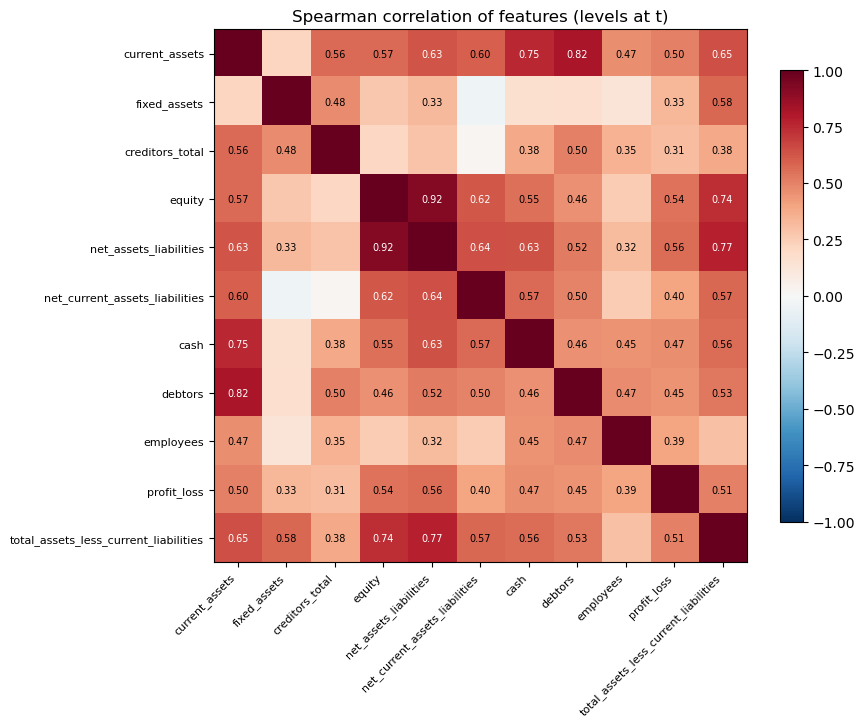

field pairs with Spearman ≥ 0.6:
equity                  net_assets_liabilities                   0.920
current_assets          debtors                                  0.816
net_assets_liabilities  total_assets_less_current_liabilities    0.775
current_assets          cash                                     0.753
equity                  total_assets_less_current_liabilities    0.736
current_assets          total_assets_less_current_liabilities    0.647
net_assets_liabilities  net_current_assets_liabilities           0.641
                        cash                                     0.635
current_assets          net_assets_liabilities                   0.629
equity                  net_current_assets_liabilities           0.618


In [30]:
# Spearman rather than Pearson: the raw scale is heavy-tailed and Pearson would be dominated by extremes. 
# Computed pairwise on rows where both fields are present.

feat = pd.DataFrame({m: train[f"{m}_t"] for m in METRICS})
fcorr = feat.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(fcorr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(fcorr)))
ax.set_xticklabels(fcorr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(fcorr)))
ax.set_yticklabels(fcorr.index, fontsize=8)
for i in range(len(fcorr)):
    for j in range(len(fcorr)):
        v = fcorr.iloc[i, j]
        if i != j and abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.6 else "black")
ax.set_title("Spearman correlation of features (levels at t)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

pairs = (fcorr.where(np.triu(np.ones(fcorr.shape), k=1).astype(bool))
         .stack().sort_values(key=abs, ascending=False))
print("field pairs with Spearman ≥ 0.6:")
print(pairs[pairs.abs() >= 0.6].round(3).to_string())

### 6.2 Levels vs changes

In [31]:
tgt = pd.DataFrame({
    m: train[f"{m}_signed_log_change"].where(
        train[f"{m}_change_eligible"].fillna(False).astype(bool))
    for m in METRICS
})
tcorr = tgt.corr(method="spearman")

mask = np.triu(np.ones(fcorr.shape), k=1).astype(bool)
comp = pd.DataFrame({
    "feature_level": fcorr.where(mask).stack(),
    "target_change": tcorr.where(mask).stack(),
})
comp["gap"] = (comp["feature_level"] - comp["target_change"]).round(3)
comp = comp.reindex(comp["feature_level"].abs().sort_values(ascending=False).index)

print("sorted by feature-side correlation:")
print(comp.head(12).round(3).to_string())
print(f"\nmedian gap (feature - target): {comp['gap'].median():.3f}")
print(f"pairs where levels correlate more strongly: "
      f"{(comp['gap'] > 0).sum()} / {len(comp)}")

sorted by feature-side correlation:
                                                              feature_level  target_change    gap
equity                 net_assets_liabilities                         0.920          0.911  0.009
current_assets         debtors                                        0.816          0.440  0.376
net_assets_liabilities total_assets_less_current_liabilities          0.775          0.757  0.018
current_assets         cash                                           0.753          0.566  0.187
equity                 total_assets_less_current_liabilities          0.736          0.718  0.017
current_assets         total_assets_less_current_liabilities          0.647          0.449  0.197
net_assets_liabilities net_current_assets_liabilities                 0.641          0.653 -0.012
                       cash                                           0.635          0.289  0.346
current_assets         net_assets_liabilities                         0.629       

### 6.3 Condition number of the Ridge design matrix

In [32]:
# computed on the actual Ridge input: the bimodal fields are split into _is_negative and _log_abs, 
# so the raw 11-column matrix is not what Ridge sees.

from numpy.linalg import cond

BIMODAL = ["equity", "net_assets_liabilities", "net_current_assets_liabilities",
           "total_assets_less_current_liabilities", "profit_loss"]

X_r = pd.DataFrame(index=train.index)
for m in METRICS:
    v = train[f"{m}_t"]
    if m in BIMODAL:
        X_r[f"{m}_is_negative"] = (v < 0).astype(float)
        X_r[f"{m}_log_abs"] = np.log1p(v.abs())
    else:
        X_r[f"{m}_sl"] = signed_log1p(v)
    X_r[f"{m}_missing"] = v.isna().astype(float)

# For diagnosis only: placeholder global-median imputation and standardisation
Xf = X_r.fillna(X_r.median())
Xs = (Xf - Xf.mean()) / Xf.std().replace(0, 1)

print(f"design matrix: {Xs.shape[0]:,} × {Xs.shape[1]}")
print(f"condition number: {cond(Xs.to_numpy()):.1f}")
print("above 30 usually means coefficients should not be read individually")

# which columns are near-duplicates
rc = Xs.corr(method="spearman")
rp = (rc.where(np.triu(np.ones(rc.shape), k=1).astype(bool))
      .stack().sort_values(key=abs, ascending=False))
print("\ncolumn pairs with spearman ≥ 0.8 in the Ridge input:")
print(rp[rp.abs() >= 0.8].round(3).to_string() if (rp.abs() >= 0.8).any() else "none")

design matrix: 65,293 × 27
condition number: 6.0
above 30 usually means coefficients should not be read individually

column pairs with spearman ≥ 0.8 in the Ridge input:
cash_missing  debtors_missing    0.801


### Reading the output

**One cluster stems from accounting identities.**
`equity` and `net_assets_liabilities` correlate at 0.920, with the other pairs among these four between 0.618 and 0.775.

A second cluster reflects containment: debtors and cash are components of current assets.

**Levels are more synchronised than changes.**
Among the 55 pairs, 51 (92.7%) correlate more strongly as levels, with a median gap of 0.226.

**Grouping for interpretation.**

- Balance-sheet scale: equity, net_assets_liabilities,TALCL, NCA
- Liquidity composition: current_assets, cash, debtors
- Standalone: creditors_total, fixed_assets, employees, profit_loss

Within a group, individual importance rankings are not interpreted; only the group's total contribution is reported.

**Ridge coefficients can be read individually.**
The design matrix has a condition number of 6, well below the conventional threshold of 30. The bimodal split adopted in §5 effectively broke up the identity cluster: two fields correlating at 0.920 on the raw scale leave no pair above 0.8 after splitting. The sole exception is `cash_missing`–`debtors_missing` at 0.801, consistent with 3.2 — their coefficients will share credit and should not be read separately.

---

### Conclusions

- Drop no features.
- Report importance by the three groups.
- Ridge coefficients may be read individually.

## 7. Shape of the feature–target relationship
At the feasibility stage, using a field's own level at t as the sole feature reached 50%–84% of the full model's skill. Most of the model's ability therefore rests on the relationship between the prior
level and the subsequent change. Its shape and strength determine how the model's behaviour should be
described.

### 7.1 A field's own level against its change

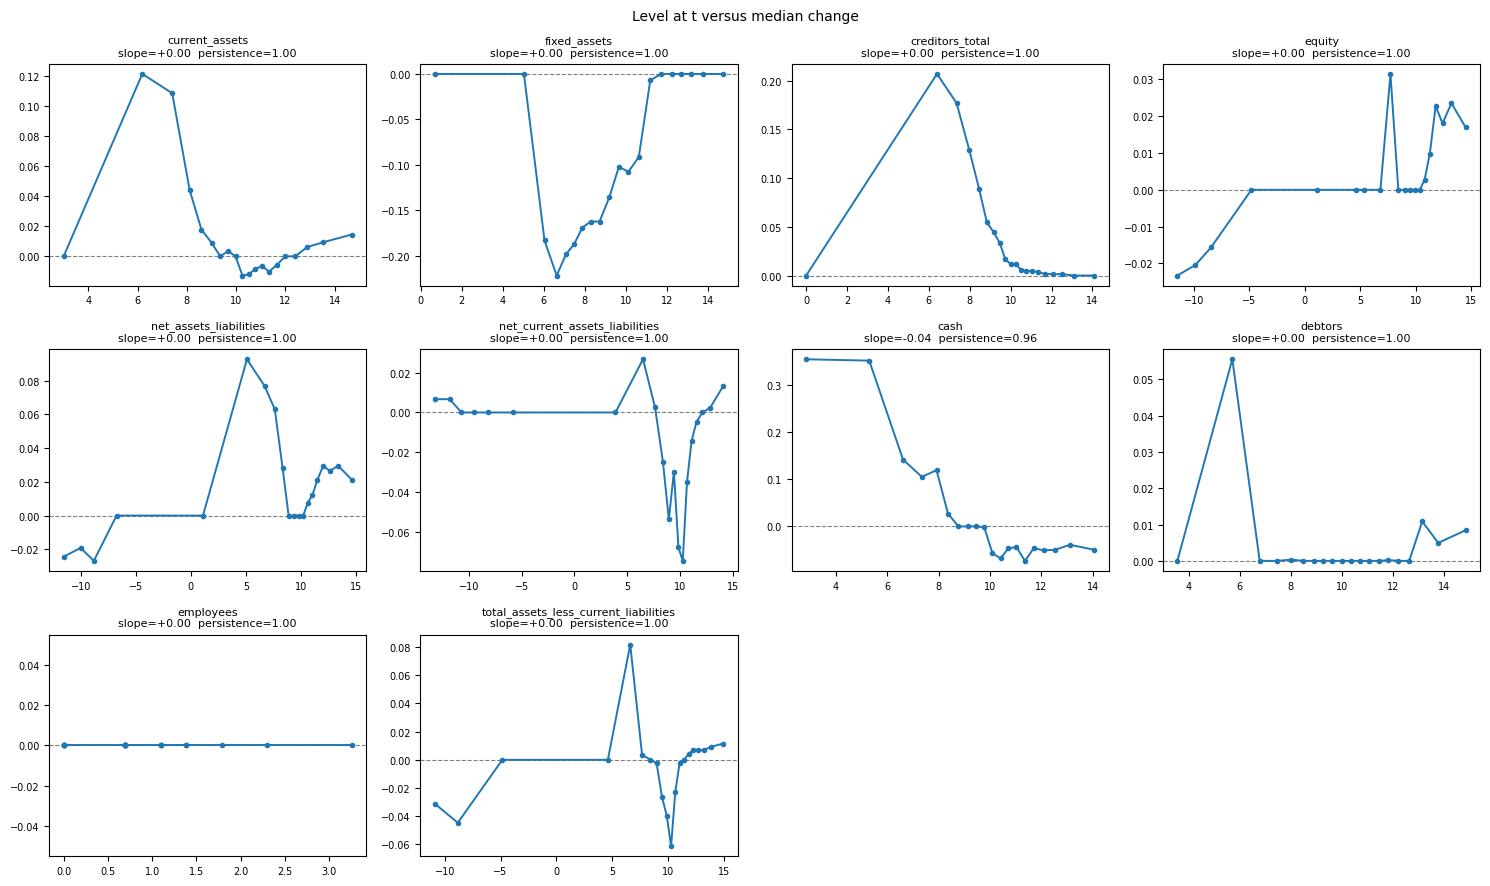

persistence = 1 + slope; 1.0 is full persistence, 0.0 is independence

                               metric     n  peak_y  peak_x  y_range  y_first_bin  y_last_bin
                       current_assets 55886   0.122   6.189    0.134        0.000       0.015
                         fixed_assets 32203   0.000   0.693    0.222        0.000       0.000
                      creditors_total 59239   0.207   6.399    0.207        0.000       0.000
                               equity 63033   0.031   7.732    0.055       -0.023       0.017
               net_assets_liabilities 53706   0.093   5.094    0.120       -0.024       0.021
       net_current_assets_liabilities 59887   0.027   6.477    0.101        0.007       0.013
                                 cash 25551   0.355   2.833    0.428        0.355      -0.050
                              debtors 21420   0.056   5.707    0.056        0.000       0.008
                            employees 61076   0.000   0.000    0.000        0.000  

In [33]:
# Binned medians, since means would be dominated by the tails
N_BINS = 20

def level_change_profile(frame, metric, n_bins=N_BINS, by=None):
    """binned median curve; `by` optionally splits into groups"""
    e = frame[f"{metric}_change_eligible"].fillna(False).astype(bool)
    sub = frame.loc[e, [f"{metric}_t", f"{metric}_signed_log_change"]
                   + ([by] if by else [])].dropna(subset=[f"{metric}_t"])
    if len(sub) < 500:
        return None
    sub = sub.assign(x=signed_log1p(sub[f"{metric}_t"]),
                     y=sub[f"{metric}_signed_log_change"])
    keys = ["bin"] + ([by] if by else [])
    sub["bin"] = pd.qcut(sub["x"].rank(method="first"), n_bins, labels=False)
    return sub.groupby(keys).agg(x=("x", "median"), y=("y", "median"), n=("y", "size"))


# curves
plot_metrics = [m for m in METRICS
                if train[f"{m}_change_eligible"].fillna(False).sum() >= 5000]
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
axes = axes.ravel()

slopes = []
for ax, m in zip(axes, plot_metrics):
    p = level_change_profile(train, m)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.plot(p["x"], p["y"], marker="o", ms=3, lw=1.4)
    # robust slope between the end bins
    slope = (p["y"].iloc[-1] - p["y"].iloc[0]) / (p["x"].iloc[-1] - p["x"].iloc[0])
    slopes.append({"metric": m, 
                   "n": int(p["n"].sum()), 
                   "peak_y": p["y"].max(),
                   "peak_x": p.loc[p["y"].idxmax(), "x"],
                   "y_range": p["y"].max() - p["y"].min(),
                   "y_first_bin": p["y"].iloc[0], 
                   "y_last_bin": p["y"].iloc[-1]})
    ax.set_title(f"{m}\nslope={slope:+.2f}  persistence={1 + slope:.2f}", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[len(plot_metrics):]:
    ax.set_visible(False)
fig.suptitle("Level at t versus median change", fontsize=10)
fig.tight_layout()
plt.show()
print("persistence = 1 + slope; 1.0 is full persistence, 0.0 is independence\n")
print(pd.DataFrame(slopes).round(3).to_string(index=False))

### 7.2 Does the shape differ by account category?

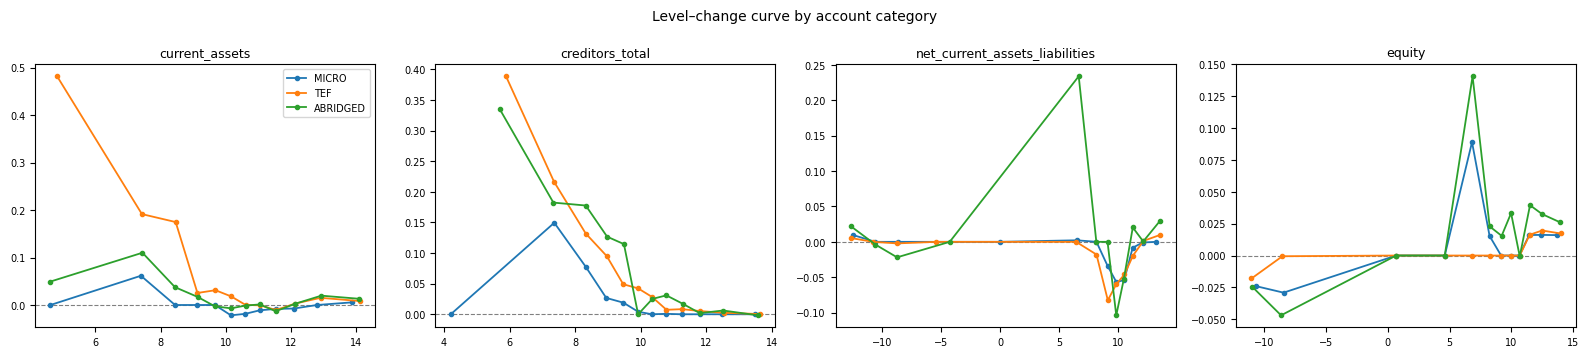

In [42]:
BIG_CATS = ["MICRO", "TEF", "ABRIDGED"]
CHECK = ["current_assets", "creditors_total", "net_current_assets_liabilities", "equity"]

fig, axes = plt.subplots(1, len(CHECK), figsize=(4 * len(CHECK), 3.6), sharey=False)
#fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, m in zip(np.atleast_1d(axes), CHECK):
    p = level_change_profile(train, m, n_bins=12, by="acct_cat_model")
    if p is None:
        continue
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    for cat in BIG_CATS:
        if cat not in p.index.get_level_values("acct_cat_model"):
            continue
        s = p.xs(cat, level="acct_cat_model")
        s = s[s["n"] >= 100] # skip sparse bins
        ax.plot(s["x"], s["y"], marker="o", ms=3, lw=1.3, label=cat)
    ax.set_title(m, fontsize=9)
    ax.tick_params(labelsize=7)

np.atleast_1d(axes)[0].legend(fontsize=7)
fig.suptitle("Level–change curve by account category", fontsize=10)
fig.tight_layout()
plt.show()

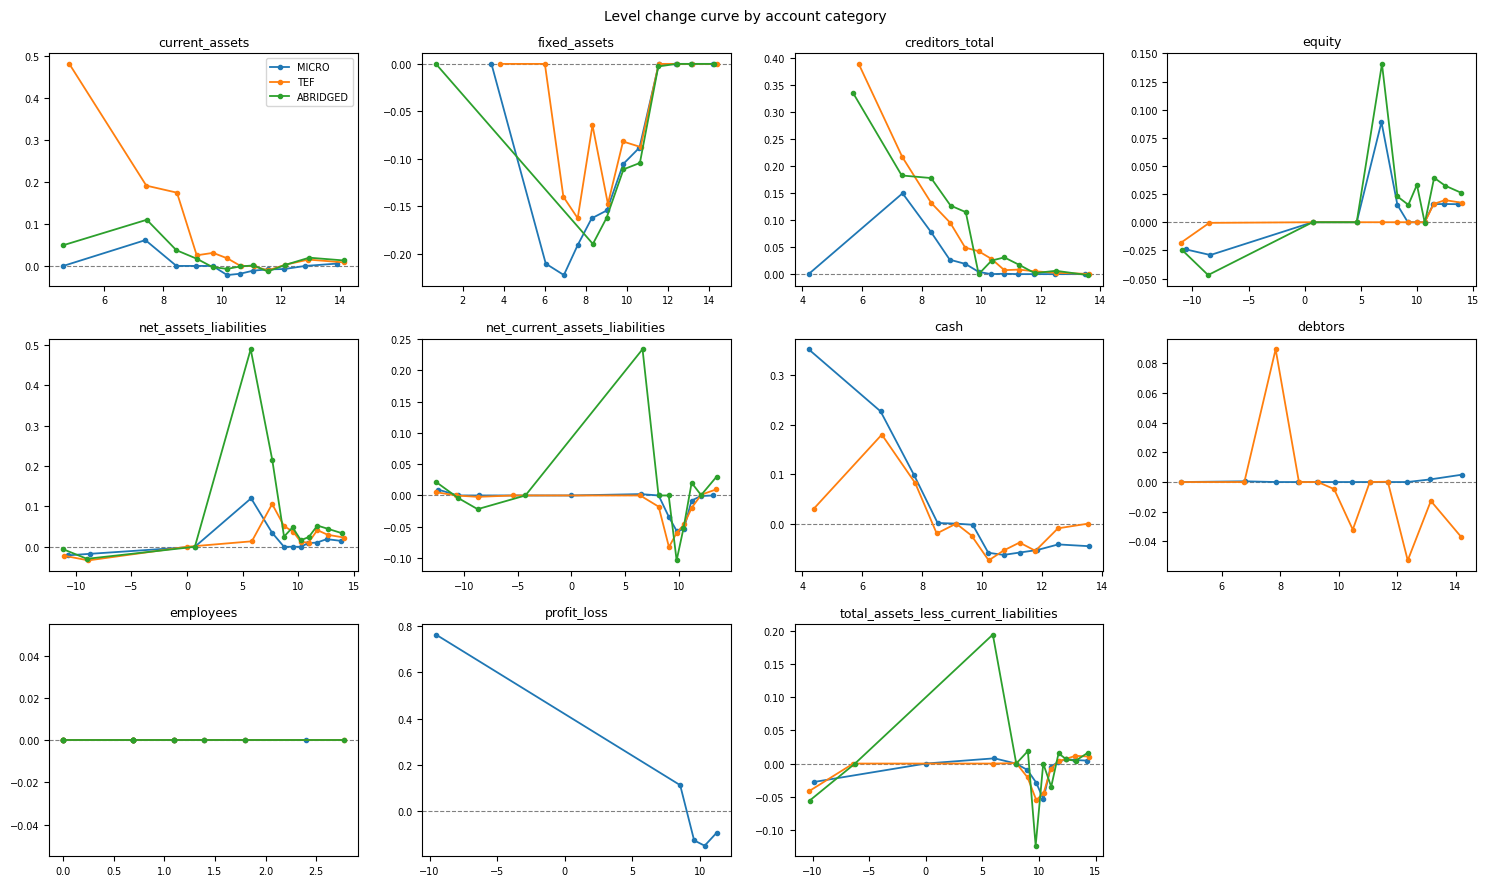

In [45]:
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
axes = axes.ravel()

for ax, m in zip(axes, METRICS):
    p = level_change_profile(train, m, n_bins=12, by="acct_cat_model")
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    if p is not None:
        for cat in BIG_CATS:
            if cat not in p.index.get_level_values("acct_cat_model"):
                continue
            s = p.xs(cat, level="acct_cat_model")
            s = s[s["n"] >= 100]          # skip sparse bins
            if len(s) >= 3:               # too few bins left to read a shape
                ax.plot(s["x"], s["y"], marker="o", ms=3, lw=1.3, label=cat)
    ax.set_title(m, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(METRICS):]:
    ax.set_visible(False)

axes[0].legend(fontsize=7)
fig.suptitle("Level change curve by account category", fontsize=10)
fig.tight_layout()
plt.show()

### Reading the output

**7.1 The relationship is hump-shaped, not linear.**
Most fields share one shape: the median change is largest where the reported value is very small, falls sharply as the level rises, and flattens to zero across the mid and upper range. For `creditors_total` the peak of +0.207 sits at x≈6.4 and the curve reaches zero beyond x≈10.

`cash` is the only field with a broadly monotone decline, `fixed_assets` carries no positive segment at all, and `employees` is flat at zero throughout.

**A linear model cannot fit this shape**
A linear model cannot fit a hump. If GBM clearly outperforms Ridge, this figure is the explanation.

**The usable signal sits at small reported values.**
The curve is nearly flat across the mid and upper range, so companies there differ little from one
another. 

What the model can separate lies mainly at the left. A very small reported value is not the same as a micro-entity.


**7.2 The curve's shape differs by account category.**
The three curves neither coincide nor run parallel. At x≈5 in `current_assets` the median change is
+0.48 for TEF, about +0.05 for ABRIDGED and near zero for MICRO; the peak of `creditors_total` also
sits at a different level for MICRO. 

A feature's relationship with the target depends on which category the company belongs to.

---

### Conclusions
Group relative-position features by `acct_cat_model`.
Add feature-by-category interactions to the Ridge branch.(optional)

## 8. Summary of EDA

---
### 8.1 Preprocessing

No fitting required; applied once to the full table.

1. Set impossible negatives to NaN in both periods.(5.1)
2. Clean 26 rows in `employees` (5.2)
3. `Accounts_AccountCategory` merge to five categories, keeping `GROUP` separate(Retain the raw eight-category column. 3.3)
4. Reduce `CompanyCategory` to a binary flag.(5.2)
5. Compute age from `IncorporationDate` and `period_t` at t.(0.5)

**Considered but rejected**

`gap_irregular`
`fixed_assets_is_zero`: the zero rate on the feature side is only 1.54%

---

### 8.2 Feature matrices
The two model families(tree&linear) share identical content — the same 11 fields, metadata, rows and folds.

Only the representation differs, so that the linearity comparison is not confounded by feature set.

| Step | GBM | Ridge | Basis |
|---|---|---|---|
| signed-log transform | √ | √ | Monotone, so it does not change tree results. Retained for consistency with the linear branch and for readable partial-dependence axes |
| 11 missing indicators | √ | √ | 3.4 disclosure is a company-level habit, so missingness is not at random.|
| Missing values | keep NaN | group-median imputation | Trees handle NaN natively. 3.1 `employees` has a 24.3% zero rate, so filling with 0 would conflate a genuine zero with an undisclosed value |
| Split bimodal fields into `_is_negative` + `_log_abs` | × | √ | 5.3 equity and four others are bimodal; a single linear coefficient cannot describe both clusters. Trees can split near zero and need no help |
| winsorise (P0.5 / P99.5) | × | √ | Clipping is useless for trees, since the ordering is unchanged(Extreme values exert leverage on linear coefficients but not on tree splits, which depend on order rather than distance. Clipping would also collapse the tails into ties, removing splits the tree could otherwise make) |
| Feature-by-category interactions | × | √ | 7.2 the curves are not parallel, so main effects alone cannot express the structure. Trees achieve this through nested splits |

**Fitted within the fold.** The winsorise cut-offs, group medians and one-hot category sets must all
be fitted on the training fold and then applied to the validation fold; fitting them on the full data
would be leakage at the preprocessing level.

---

### 8.3 Modelling and evaluation

| Decision | Basis |
|---|---|
| Use quantile loss (q=0.5), not squared loss | 4.2 among the four sign-permitted fields(except `profit_loss`), the 6.5%–10.9% of rows that cross zero carry 88.5%–95.4% of the squared deviation, so squared loss would concentrate its optimisation weight on them |
| Evaluate with rank-based metrics: discrimination rate, pairwise accuracy, Spearman | 4.1 `tail_ratio` reaches 10.8–76.2 against about 3.4 under normality; RMSE, R² and skill all rest on the same squared deviation |
| Decile profiles on medians, means for reference only | §4.1 heavy tails. At the feasibility stage `equity` showed a mean decile separation of 6.69 against a median separation of 0.009 |
| Report every metric alongside `zero_frac` | 4.1 `employees` 73.3%, `fixed_assets` 24.0% Zero-inflation determines how strong the "no change" baseline is, so metrics are not comparable across fields |
| Split grouped by company | 2.1 12.19% of rows come from companies contributing more than one pair, where the middle period is both the t+1 of one pair and the t of the next |
| Report feature importance by group | 6.1 correlations reach 0.920 within the identity cluster; GBM's choice between correlated features is near-arbitrary|
| Ridge coefficients may be read individually | 6.3 the design matrix has a condition number of 6.0, well below 30 |
| Keep all 11 fields as targets; flag `profit_loss` results as unreliable | 4.1 n = 2,351 with the widest spread of any field. Retained for comparison but excluded from conclusions |


---

### 8.4 An ablation

**Within-group relative position**: Each field's percentile within its `acct_cat_model` group which is tested separately on the GBM and Ridge branches.

**Why only this one.** The other candidates (missing indicators, merging the `cash`/`debtors`
indicators, a `tier_changed` feature) involve no real trade-off: keeping them costs a few columns and
the model decides for itself whether to use them. Relative position is different, it requires a set
of group statistics fitted within each fold.

**Grouping.** By `acct_cat_model`.


---

### 8.5 Observations to confirm at the evaluation stage

Observed during the EDA but not yet established. These are checked later, not assumed.

| Observation | Check |
|---|---|
| Ranking ability may concentrate at small reported values | Split `_t` into five bands by level and compute pairwise accuracy within each |
| MICRO may be less predictable. Its curve is flat and it is 55.2% of the sample | Stratify results by `acct_cat_raw` |
| Any gap between Ridge and GBM should be explained by the hump-shaped relationship in 7.1 | model comparison |

---

### 8.6 Limitations

**Extreme values are not truncated.** Apart from `employees`, every field retains its original values. Company size spans six orders of magnitude, so a parsing error cannot be distinguished from a genuinely large company on the number alone. Trees split on order and the final output is a ranking, which limits the impact — at the cost of any residual parsing errors entering the model silently.

**The cause of the negative values is unverified.** Their magnitudes match the fields' normal values
with only the sign differing. They are treated as untrustworthy.

**Low-coverage fields do not extrapolate.** Missingness in `cash` (39.1%), `debtors` (32.8%) and `fixed_assets` (49.3%) is largely determined by account category, so their models train on a population skewed toward fuller disclosers and their results do not apply to companies that never disclose those fields.

**The sample is pre-filtered.** Every company in the metadata has `CompanyStatus` = Active, so dissolved companies are excluded by construction. This is a second layer of survivorship bias on top of the requirement that the t+1 accounts have already been filed.